In [2]:
!pip install kagglehub

In [298]:
import random
import cv2
import numpy as np
import pickle
import os
from collections import defaultdict

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import accuracy_score, precision_score, recall_score

from extract_embedding import FaceEmbedder
from face_recognizer import FaceRecognizer
from train_model import FaceTrainer

## Load LFW Data

In [94]:
lfw = fetch_lfw_people(min_faces_per_person=0, resize=0.5)

In [134]:
def load_lfw_dataset(num_people, min_images_per_person):

    embedder = FaceEmbedder()

    # Randomly shuffle dataset indices first
    all_indices = list(range(len(lfw.images)))
    random.shuffle(all_indices)

    # Map person -> indices
    person_to_indices = defaultdict(list)

    for idx in all_indices:
        label_idx = lfw.target[idx]
        person_name = lfw.target_names[label_idx]
        person_to_indices[person_name].append(idx)

    # Filter people with enough images
    eligible_people = [
        p for p, idxs in person_to_indices.items()
        if len(idxs) >= min_images_per_person
    ]

    if len(eligible_people) < num_people:
        print(f"there are {len(eligible_people)} eligible people for min images: {min_images_per_person}")
        return [], []

    # Randomly choose people
    selected_people = random.sample(eligible_people, num_people)

    embeddings = []
    labels = []

    for person_name in selected_people:

        indices = person_to_indices[person_name]

        # Randomly select images
        selected_indices = random.sample(indices, min_images_per_person)

        for idx in selected_indices:

            img = lfw.images[idx]

            if img.ndim == 2:
                img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            else:
                img_bgr = img

            img_bgr = cv2.resize(img_bgr, (300, 300))

            embedding = embedder.get_embedding(img_bgr)

            embeddings.append(embedding)
            labels.append(person_name)

    return embeddings, labels

In [147]:
load_lfw_dataset(10, 150)

there are 2 eligible people for min images: 150


([], [])

### Prior to loading user data for training, embedding of their data needs to be done

images/video uploaded --> calculate/extract embedding --> load user data --> train with lfw data

In [223]:
def load_user_data(embedding_file_name: str):

    with open(embedding_file_name, "rb") as f:
        data = pickle.load(f)

    X = data["embeddings"]
    y = data["labels"]

    unique_y = list(set(y))

    return X, y, unique_y

In [232]:
def combine_dataset(num_people = 5, num_images = 100):
    X_lfw, y_lfw = load_lfw_dataset(num_people, num_images)
    X_user, y_user, _ = load_user_data("embeddings.pkl")

    X = np.vstack((X_lfw, X_user))
    y = np.concatenate((y_lfw, y_user))

    return X, y

In [227]:
def split_train_test(X, y, test_size_ = 0.2, random_state_ = 42):

    le = LabelEncoder()
    y_encoded = le.fit_transform(y)  
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size = test_size_, stratify=y_encoded, random_state=random_state_
    )

    return le, X_train, X_test, y_train, y_test

## Train KNN

In [230]:
def train_save_model(file_path: str):
    
    X, y = combine_dataset()
    le, X_train, X_test, y_train, y_test = split_train_test(X, y)

    model = KNeighborsClassifier(n_neighbors=3)

    model.fit(X_train, y_train)

    with open(file_path, "wb") as f:
        pickle.dump((model, le, X_train, X_test, y_train, y_test), f)

    print(f"[INFO] Model saved to {file_path}")

In [234]:
file_path = "pretrained_knn.pkl"

train_save_model(file_path)

[INFO] Model saved to pretrained_knn.pkl


## Predict with KNN

* Pass list of names we want to predict (from users data)
* Return everything else outside of the list as unknown (by checking predicted name after)

In [248]:
def load_model(model_file):
    
    if not os.path.exists(model_file):
        raise FileNotFoundError(f"Model file not found: {model_file}")

    with open(model_file, "rb") as f:
        model, le, X_train, X_test, y_train, y_test = pickle.load(f)
    print(f"[INFO] Model loaded from {model_file}")

    return model, le, X_train, X_test, y_train, y_test

In [252]:
def predict(model, label_encoder, X, y, threshold = 0.5): # use test data

    if model is None:
        raise ValueError("Model not trained or loaded.")

    preds = model.predict(X)
    probs = model.predict_proba(X).max(axis = 1)

    results = []
    
    for pred, prob in zip(preds, probs):
        name = label_encoder.inverse_transform([pred])[0]
        
        if prob < threshold:
            name = "Unknown"
            
        results.append({"name": name, "probability": prob})

    return results

In [256]:
def convert_to_unknowns(names_list, results):

    converted_results = []

    for result in results:
        name = result["name"]

        if name != "Unknown" and name not in names_list:
            name = "Unknown"

        converted_results.append({
            "name": name,
            "probability": result["probability"]
        })

    return converted_results

## Accuracy

In [258]:
_, _, names_list = load_user_data("embeddings.pkl")

knn_model, le, X_train, X_test, y_train, y_test = load_model("pretrained_knn.pkl")

raw_results = predict(knn_model, le, X_test, y_test)
converted_results = convert_to_unknowns(names_list, raw_results)

[INFO] Model loaded from pretrained_knn.pkl


In [279]:
y_true = le.inverse_transform(y_test)
y_true_converted = []

for name in y_true:
    if name != "Unknown" and name not in names_list:
        name = "Unknown"
    y_true_converted.append(name)

In [285]:
def score_accuracy(y_true, results):
    
    y_pred = [r["name"] for r in results]

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)

    # Macro precision / recall
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)

    # Error rate
    error_rate = 1 - accuracy

    return {
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "error_rate": error_rate
    }

In [287]:
score_report = score_accuracy(y_true_converted, converted_results)

In [289]:
score_report

{'accuracy': 0.9699248120300752,
 'precision_macro': 0.972327868852459,
 'recall_macro': 0.9594974600870827,
 'error_rate': 0.03007518796992481}

## Confusion Matrix

In [300]:
def plot_confusion_heatmap(y_true, results, figsize=(8,6), cmap="Blues"):

    # Extract predictions
    y_pred = [r["name"] for r in converted_results]

    # Get all unique classes (include 'Unknown')
    classes = sorted(list(set(y_true) | set(y_pred)))

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=classes)

    # Plot heatmap
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes, cmap=cmap)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix Heatmap")
    plt.show()

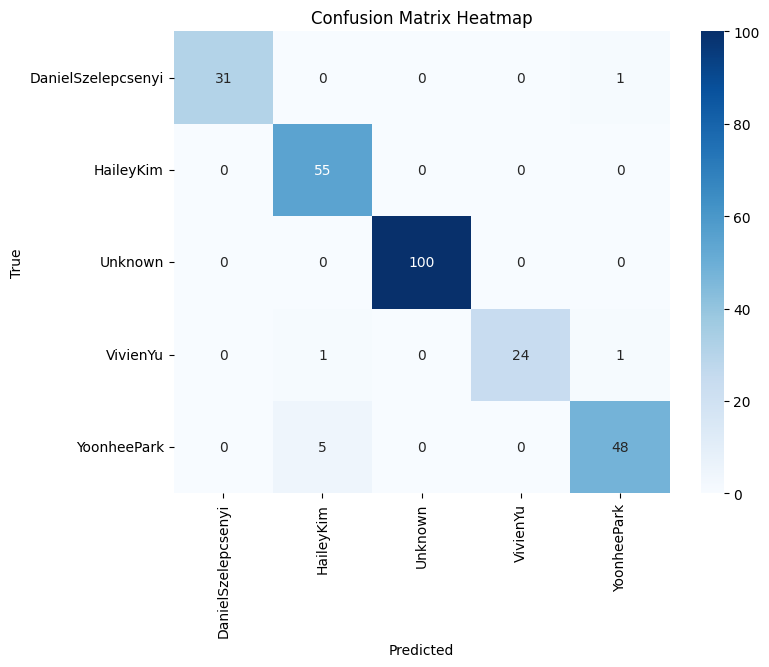

In [308]:
plot_confusion_heatmap(y_true_converted, converted_results)

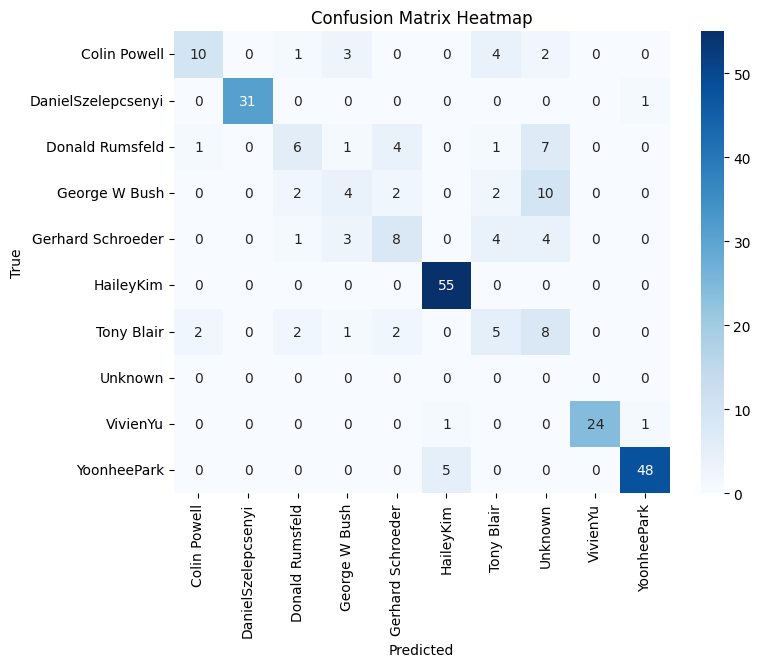

In [306]:
plot_confusion_heatmap(y_true, raw_results)

# Original Plan: Pretrain KNN --> Update model with updated data

Problem: KNN needs to be retrained when there are more data

## Train KNN and Extract Pretrained KNN Model

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [ ]:
def pretrain_knn(num_people, min_images, file_path):

    embeddings, labels = load_lfw_dataset(num_people, min_images)
    
    X = np.array(embeddings)
    y = np.array(labels)
    
    # ----------------- Encode labels -----------------
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)  # now labels are 0..n_classes-1

    # ----------------- Train/test split -----------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
    )

    print(f"[INFO] Number of classes: {len(le.classes_)}")
    print(f"[INFO] Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

    model = KNeighborsClassifier(n_neighbors=3)
    model.fit(X_train, y_train)

    with open(file_path, "wb") as f:
        pickle.dump((self.model, self.label_encoder), f)
        
    print(f"[INFO] Model saved to {file_path}")

In [ ]:
file_path = "pretrained_knn"

pretrain_knn(10, 100, file_path)